<a href="https://colab.research.google.com/github/rubyat43/220143_DT_Decision_Tree/blob/main/220143_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Load Data from GitHub.***

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/rubyat43/220143_Neural_Network_NN/refs/heads/main/heart.csv"
df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


# ***Deep Data Exploration.***

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


# ***Statistical summary of all numeric columns.***

In [3]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# ***Check class balance of the target variable.***

In [4]:
print(df['target'].value_counts())
print()
print(df['target'].value_counts(normalize=True) * 100)

target
1    165
0    138
Name: count, dtype: int64

target
1    54.455446
0    45.544554
Name: proportion, dtype: float64


# ***Visualizing Distributions (Histograms) + Outlier Detection.***

# **Histograms.**

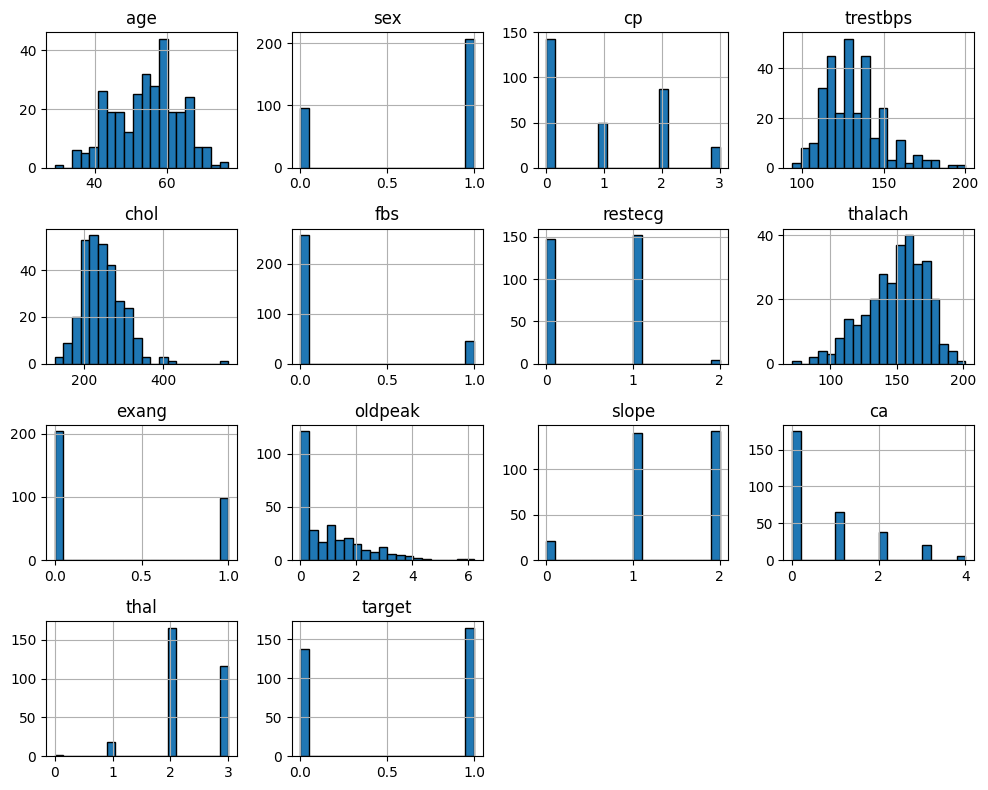

In [5]:
import matplotlib.pyplot as plt

df.hist(figsize=(10, 8), bins=20, edgecolor='black')
plt.tight_layout()
plt.savefig('histograms.png', dpi=100)
plt.show()

# **Check for biologically impossible or suspicious values.**

In [6]:
print("Minimum cholesterol:", df['chol'].min())
print("Minimum resting blood pressure:", df['trestbps'].min())
print("Minimum max heart rate:", df['thalach'].min())

Minimum cholesterol: 126
Minimum resting blood pressure: 94
Minimum max heart rate: 71


# ***Correlation Analysis.***

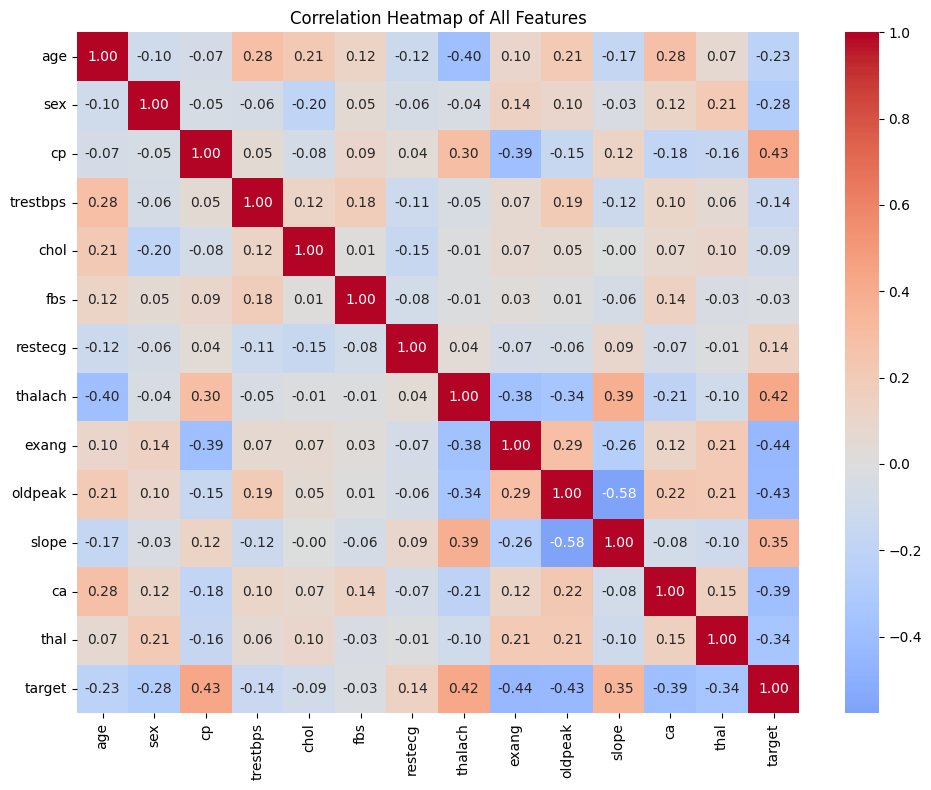

In [7]:
import seaborn as sns

plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of All Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100)
plt.show()

# **One focused visual.**

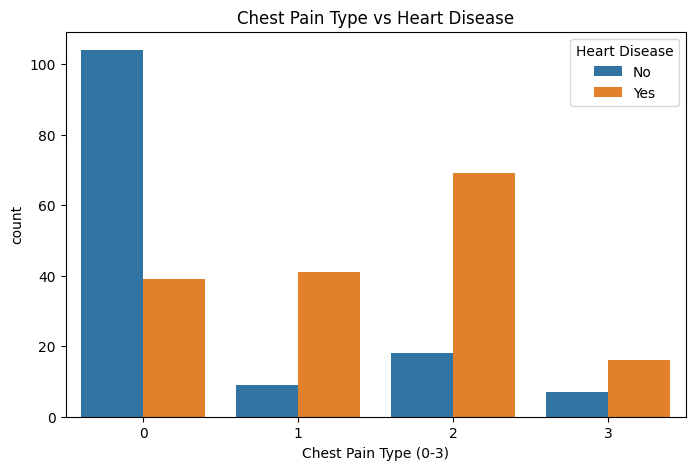

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='cp', hue='target')
plt.title('Chest Pain Type vs Heart Disease')
plt.xlabel('Chest Pain Type (0-3)')
plt.legend(title='Heart Disease', labels=['No', 'Yes'])
plt.savefig('cp_vs_target.png', dpi=100)
plt.show()

# ***Data Preprocessing.***

# **One-Hot Encode the categorical columns.**

In [9]:
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Original shape:", df.shape)
print("After encoding shape:", df_encoded.shape)
df_encoded.head()

Original shape: (303, 14)
After encoding shape: (303, 20)


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_1,thal_2,thal_3
0,63,1,145,233,1,150,0,2.3,0,1,False,False,True,False,False,False,False,True,False,False
1,37,1,130,250,0,187,0,3.5,0,1,False,True,False,True,False,False,False,False,True,False
2,41,0,130,204,0,172,0,1.4,0,1,True,False,False,False,False,False,True,False,True,False
3,56,1,120,236,0,178,0,0.8,0,1,True,False,False,True,False,False,True,False,True,False
4,57,0,120,354,0,163,1,0.6,0,1,False,False,False,True,False,False,True,False,True,False


# **Separate features (X) and target (y).**

In [10]:
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (303, 19)
Target shape: (303,)


# **Stratified Train/Test split (80/20).**

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target balance:\n", y_train.value_counts(normalize=True))
print("Test target balance:\n", y_test.value_counts(normalize=True))

Train shape: (242, 19)
Test shape: (61, 19)
Train target balance:
 target
1    0.545455
0    0.454545
Name: proportion, dtype: float64
Test target balance:
 target
1    0.540984
0    0.459016
Name: proportion, dtype: float64


# **Scale the features.**

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Mean of scaled training data (should be ~0):", X_train_scaled.mean())
print("Std of scaled training data (should be ~1):", X_train_scaled.std())

Mean of scaled training data (should be ~0): 2.7622773818424947e-17
Std of scaled training data (should be ~1): 1.0


# ***Shallow Neural Network (PyTorch).***

# **Convert data to PyTorch tensors.**

In [13]:
import torch
import torch.nn as nn
import numpy as np

from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, stratify=y_train, random_state=42
)

X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr.values, dtype=torch.float32).view(-1, 1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print("Train:", X_tr_t.shape, "Val:", X_val_t.shape, "Test:", X_test_t.shape)

Train: torch.Size([193, 19]) Val: torch.Size([49, 19]) Test: torch.Size([61, 19])


# ** Define the Shallow Network architecture.**

In [14]:
class ShallowNN(nn.Module):
    def __init__(self, input_dim, hidden_units, activation):
        super().__init__()
        self.layer1 = nn.Linear(input_dim, hidden_units)
        self.activation = activation
        self.output_layer = nn.Linear(hidden_units, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.layer1(x)
        x = self.activation(x)
        x = self.output_layer(x)
        x = self.sigmoid(x)
        return x

# **Hyperparameter Tuning loop (hidden units, activation, batch size).**

In [15]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

def train_and_evaluate(hidden_units, activation, batch_size, epochs=50):
    model = ShallowNN(input_dim=X_tr_t.shape[1], hidden_units=hidden_units, activation=activation)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    train_dataset = TensorDataset(X_tr_t, y_tr_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_t)
        val_preds = (val_outputs >= 0.5).float()
        val_acc = (val_preds == y_val_t).float().mean().item()

    return val_acc, model

configs = [
    (8, nn.ReLU(), 16),
    (16, nn.ReLU(), 16),
    (16, nn.Sigmoid(), 16),
    (32, nn.ReLU(), 32),
]

results = []
for hidden_units, activation, batch_size in configs:
    val_acc, _ = train_and_evaluate(hidden_units, activation, batch_size)
    results.append((hidden_units, activation.__class__.__name__, batch_size, val_acc))
    print(f"Hidden units: {hidden_units}, Activation: {activation.__class__.__name__}, Batch size: {batch_size} -> Val Accuracy: {val_acc:.4f}")

Hidden units: 8, Activation: ReLU, Batch size: 16 -> Val Accuracy: 0.8367
Hidden units: 16, Activation: ReLU, Batch size: 16 -> Val Accuracy: 0.7755
Hidden units: 16, Activation: Sigmoid, Batch size: 16 -> Val Accuracy: 0.8571
Hidden units: 32, Activation: ReLU, Batch size: 32 -> Val Accuracy: 0.8163


# **Train the final Shallow NN with the best config.**

In [16]:
def train_with_history(hidden_units, activation, batch_size, epochs=50):
    model = ShallowNN(input_dim=X_tr_t.shape[1], hidden_units=hidden_units, activation=activation)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    train_dataset = TensorDataset(X_tr_t, y_tr_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        model.eval()
        with torch.no_grad():
            train_out = model(X_tr_t)
            train_loss = criterion(train_out, y_tr_t).item()
            train_acc = ((train_out >= 0.5).float() == y_tr_t).float().mean().item()

            val_out = model(X_val_t)
            val_loss = criterion(val_out, y_val_t).item()
            val_acc = ((val_out >= 0.5).float() == y_val_t).float().mean().item()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

    return model, history

shallow_model, shallow_history = train_with_history(
    hidden_units=16, activation=nn.Sigmoid(), batch_size=16, epochs=50
)

print("Final Shallow NN trained.")
print("Final train accuracy:", shallow_history['train_acc'][-1])
print("Final val accuracy:", shallow_history['val_acc'][-1])

Final Shallow NN trained.
Final train accuracy: 0.8808290362358093
Final val accuracy: 0.8163265585899353


# ***Build the Deep Neural Network.***

# **Define the Deep Network architecture.**

In [17]:
class DeepNN(nn.Module):
    def __init__(self, input_dim, hidden_units_list, dropout_rate):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_units_list:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# **Hyperparameter tuning — learning rate, optimizer (Adam vs SGD), epochs.**

In [18]:
def train_deep_and_evaluate(hidden_units_list, dropout_rate, lr, optimizer_name, epochs, weight_decay=0.0):
    model = DeepNN(input_dim=X_tr_t.shape[1], hidden_units_list=hidden_units_list, dropout_rate=dropout_rate)
    criterion = nn.BCELoss()

    if optimizer_name == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_dataset = TensorDataset(X_tr_t, y_tr_t)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_t)
        val_preds = (val_outputs >= 0.5).float()
        val_acc = (val_preds == y_val_t).float().mean().item()

    return val_acc

deep_configs = [
    ([32, 16, 8], 0.3, 0.01, 'adam', 50, 0.0),
    ([32, 16, 8], 0.3, 0.001, 'adam', 100, 0.0),
    ([32, 16, 8], 0.3, 0.01, 'sgd', 100, 0.0),
    ([32, 16, 8], 0.3, 0.001, 'adam', 100, 1e-4),
]

for hidden_list, dropout, lr, opt_name, epochs, wd in deep_configs:
    val_acc = train_deep_and_evaluate(hidden_list, dropout, lr, opt_name, epochs, wd)
    print(f"LR={lr}, Optimizer={opt_name}, Epochs={epochs}, WeightDecay={wd} -> Val Accuracy: {val_acc:.4f}")

LR=0.01, Optimizer=adam, Epochs=50, WeightDecay=0.0 -> Val Accuracy: 0.8163
LR=0.001, Optimizer=adam, Epochs=100, WeightDecay=0.0 -> Val Accuracy: 0.7755
LR=0.01, Optimizer=sgd, Epochs=100, WeightDecay=0.0 -> Val Accuracy: 0.8367
LR=0.001, Optimizer=adam, Epochs=100, WeightDecay=0.0001 -> Val Accuracy: 0.8163


# **Train the final Deep NN with full history tracking.**

In [19]:
def train_deep_with_history(hidden_units_list, dropout_rate, lr, optimizer_name, epochs, weight_decay=0.0):
    model = DeepNN(input_dim=X_tr_t.shape[1], hidden_units_list=hidden_units_list, dropout_rate=dropout_rate)
    criterion = nn.BCELoss()

    if optimizer_name == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_dataset = TensorDataset(X_tr_t, y_tr_t)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            train_out = model(X_tr_t)
            train_loss = criterion(train_out, y_tr_t).item()
            train_acc = ((train_out >= 0.5).float() == y_tr_t).float().mean().item()

            val_out = model(X_val_t)
            val_loss = criterion(val_out, y_val_t).item()
            val_acc = ((val_out >= 0.5).float() == y_val_t).float().mean().item()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

    return model, history

deep_model, deep_history = train_deep_with_history(
    hidden_units_list=[32, 16, 8], dropout_rate=0.3, lr=0.01,
    optimizer_name='sgd', epochs=100, weight_decay=0.0
)

print("Final Deep NN trained.")
print("Final train accuracy:", deep_history['train_acc'][-1])
print("Final val accuracy:", deep_history['val_acc'][-1])

Final Deep NN trained.
Final train accuracy: 0.8393782377243042
Final val accuracy: 0.8163265585899353


# ***Required Visualizations.***

# **Training History (Loss & Accuracy curves).**

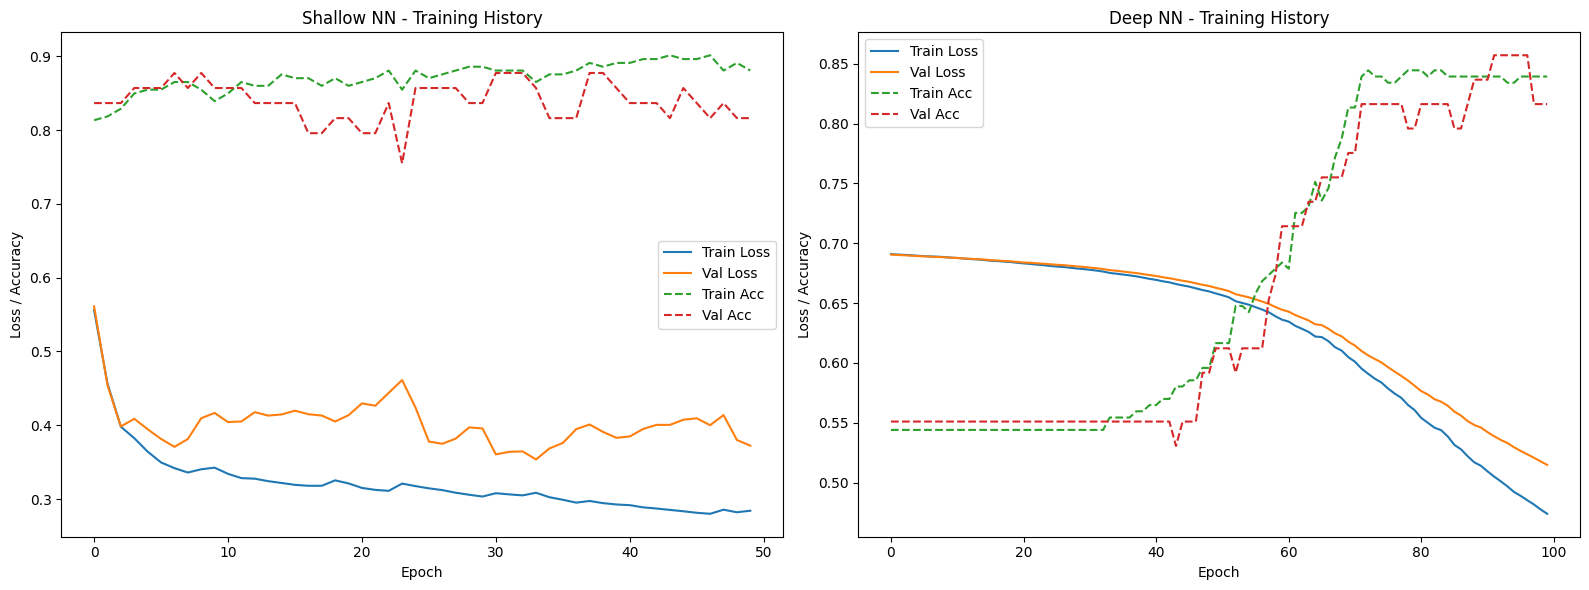

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(shallow_history['train_loss'], label='Train Loss')
axes[0].plot(shallow_history['val_loss'], label='Val Loss')
axes[0].plot(shallow_history['train_acc'], label='Train Acc', linestyle='--')
axes[0].plot(shallow_history['val_acc'], label='Val Acc', linestyle='--')
axes[0].set_title('Shallow NN - Training History')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss / Accuracy')
axes[0].legend()

axes[1].plot(deep_history['train_loss'], label='Train Loss')
axes[1].plot(deep_history['val_loss'], label='Val Loss')
axes[1].plot(deep_history['train_acc'], label='Train Acc', linestyle='--')
axes[1].plot(deep_history['val_acc'], label='Val Acc', linestyle='--')
axes[1].set_title('Deep NN - Training History')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss / Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_history_comparison.png', dpi=100)
plt.show()

# **Confusion Matrix Heatmaps.**

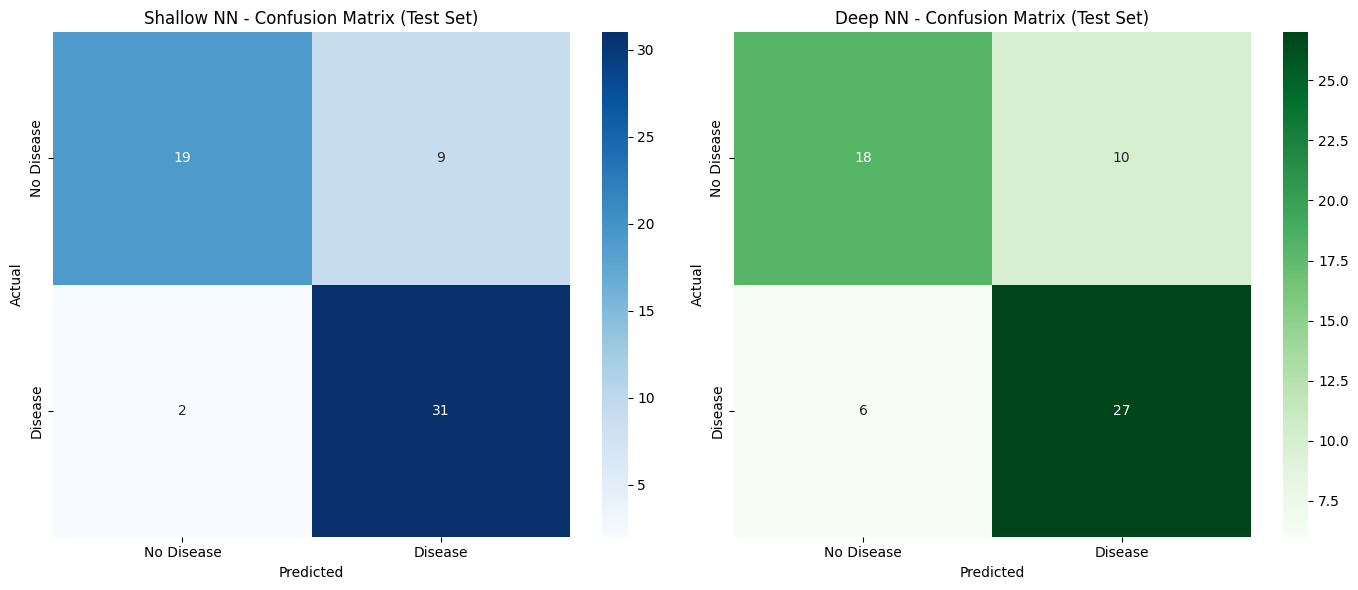

In [21]:
from sklearn.metrics import confusion_matrix

shallow_model.eval()
deep_model.eval()

with torch.no_grad():
    shallow_test_preds = (shallow_model(X_test_t) >= 0.5).float().numpy().flatten()
    deep_test_preds = (deep_model(X_test_t) >= 0.5).float().numpy().flatten()

y_test_np = y_test_t.numpy().flatten()

cm_shallow = confusion_matrix(y_test_np, shallow_test_preds)
cm_deep = confusion_matrix(y_test_np, deep_test_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_shallow, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'], ax=axes[0])
axes[0].set_title('Shallow NN - Confusion Matrix (Test Set)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'], ax=axes[1])
axes[1].set_title('Deep NN - Confusion Matrix (Test Set)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png', dpi=100)
plt.show()

# **ROC Curve & AUC.**

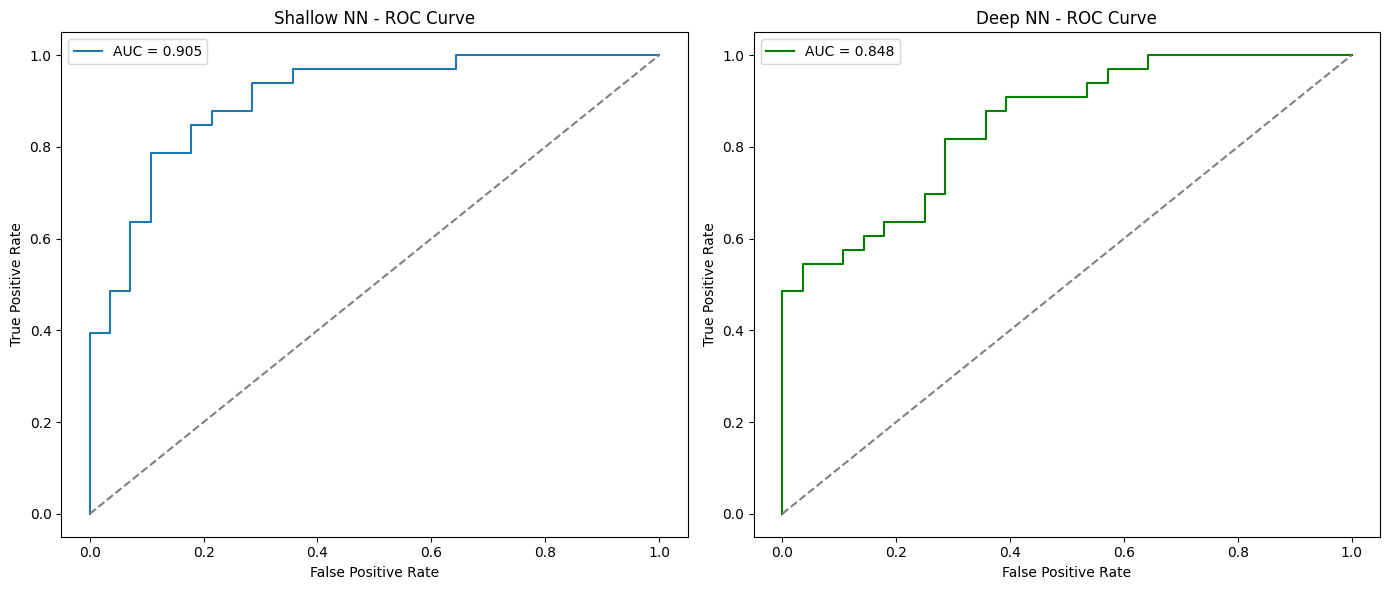

Shallow NN AUC: 0.9048
Deep NN AUC: 0.8485


In [22]:
from sklearn.metrics import roc_curve, auc

with torch.no_grad():
    shallow_test_probs = shallow_model(X_test_t).numpy().flatten()
    deep_test_probs = deep_model(X_test_t).numpy().flatten()

fpr_shallow, tpr_shallow, _ = roc_curve(y_test_np, shallow_test_probs)
roc_auc_shallow = auc(fpr_shallow, tpr_shallow)

fpr_deep, tpr_deep, _ = roc_curve(y_test_np, deep_test_probs)
roc_auc_deep = auc(fpr_deep, tpr_deep)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(fpr_shallow, tpr_shallow, label=f'AUC = {roc_auc_shallow:.3f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title('Shallow NN - ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

axes[1].plot(fpr_deep, tpr_deep, label=f'AUC = {roc_auc_deep:.3f}', color='green')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title('Deep NN - ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('roc_curve_comparison.png', dpi=100)
plt.show()

print(f"Shallow NN AUC: {roc_auc_shallow:.4f}")
print(f"Deep NN AUC: {roc_auc_deep:.4f}")

# **Grouped Bar Chart (Accuracy, Precision, Recall, F1, AUC — combined comparison).**

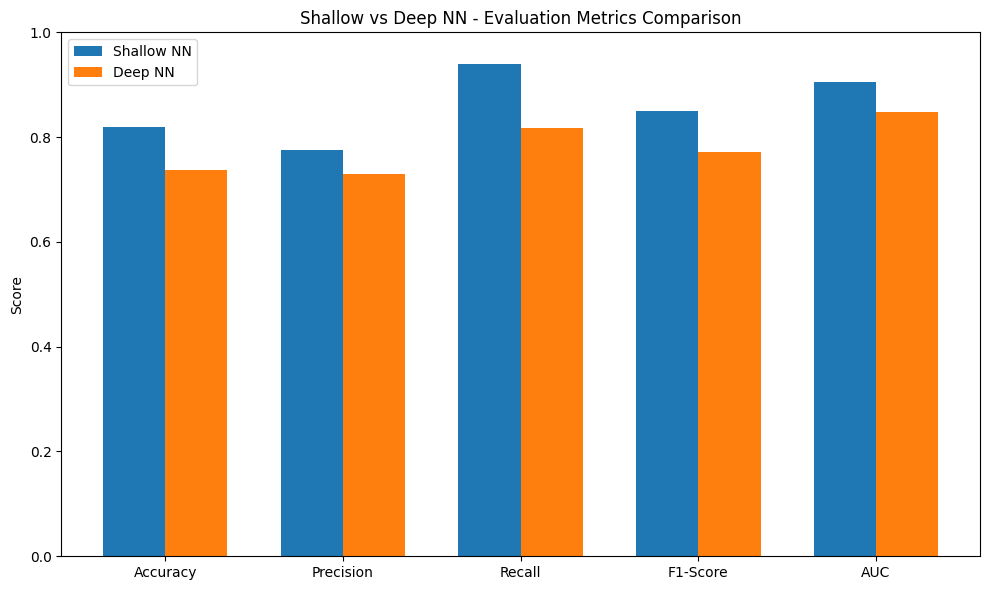

Shallow NN metrics: {'Accuracy': 0.819672131147541, 'Precision': 0.775, 'Recall': 0.9393939393939394, 'F1-Score': 0.8493150684931506, 'AUC': np.float64(0.9047619047619048)}
Deep NN metrics: {'Accuracy': 0.7377049180327869, 'Precision': 0.7297297297297297, 'Recall': 0.8181818181818182, 'F1-Score': 0.7714285714285715, 'AUC': np.float64(0.8484848484848485)}


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics_shallow = {
    'Accuracy': accuracy_score(y_test_np, shallow_test_preds),
    'Precision': precision_score(y_test_np, shallow_test_preds),
    'Recall': recall_score(y_test_np, shallow_test_preds),
    'F1-Score': f1_score(y_test_np, shallow_test_preds),
    'AUC': roc_auc_shallow
}

metrics_deep = {
    'Accuracy': accuracy_score(y_test_np, deep_test_preds),
    'Precision': precision_score(y_test_np, deep_test_preds),
    'Recall': recall_score(y_test_np, deep_test_preds),
    'F1-Score': f1_score(y_test_np, deep_test_preds),
    'AUC': roc_auc_deep
}

labels = list(metrics_shallow.keys())
shallow_vals = list(metrics_shallow.values())
deep_vals = list(metrics_deep.values())

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, shallow_vals, width, label='Shallow NN')
ax.bar(x + width/2, deep_vals, width, label='Deep NN')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Score')
ax.set_title('Shallow vs Deep NN - Evaluation Metrics Comparison')
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('metrics_bar_chart.png', dpi=100)
plt.show()

print("Shallow NN metrics:", metrics_shallow)
print("Deep NN metrics:", metrics_deep)

# **Network Structure (Sequential Output).**

In [24]:
print("SHALLOW NEURAL NETWORK ARCHITECTURE:")
print("\n")
print(shallow_model)

print("\n" + "*" * 50)
print("DEEP NEURAL NETWORK ARCHITECTURE")
print("*" * 50)
print(deep_model)

SHALLOW NEURAL NETWORK ARCHITECTURE:


ShallowNN(
  (layer1): Linear(in_features=19, out_features=16, bias=True)
  (activation): Sigmoid()
  (output_layer): Linear(in_features=16, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

**************************************************
DEEP NEURAL NETWORK ARCHITECTURE
**************************************************
DeepNN(
  (network): Sequential(
    (0): Linear(in_features=19, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=8, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


# **Clean table (layer name, output shape, parameter count).**

In [25]:
!pip install torchinfo -q

from torchinfo import summary

print("SHALLOW NN SUMMARY")
summary(shallow_model, input_size=(1, X_tr_t.shape[1]))

print("\nDEEP NN SUMMARY")
summary(deep_model, input_size=(1, X_tr_t.shape[1]))

SHALLOW NN SUMMARY

DEEP NN SUMMARY


Layer (type:depth-idx)                   Output Shape              Param #
DeepNN                                   [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 32]                   640
│    └─ReLU: 2-2                         [1, 32]                   --
│    └─Dropout: 2-3                      [1, 32]                   --
│    └─Linear: 2-4                       [1, 16]                   528
│    └─ReLU: 2-5                         [1, 16]                   --
│    └─Dropout: 2-6                      [1, 16]                   --
│    └─Linear: 2-7                       [1, 8]                    136
│    └─ReLU: 2-8                         [1, 8]                    --
│    └─Dropout: 2-9                      [1, 8]                    --
│    └─Linear: 2-10                      [1, 1]                    9
│    └─Sigmoid: 2-11                     [1, 1]                    --
Total params:

# **An actual visual diagram (graph image).**

Shallow NN Graph:


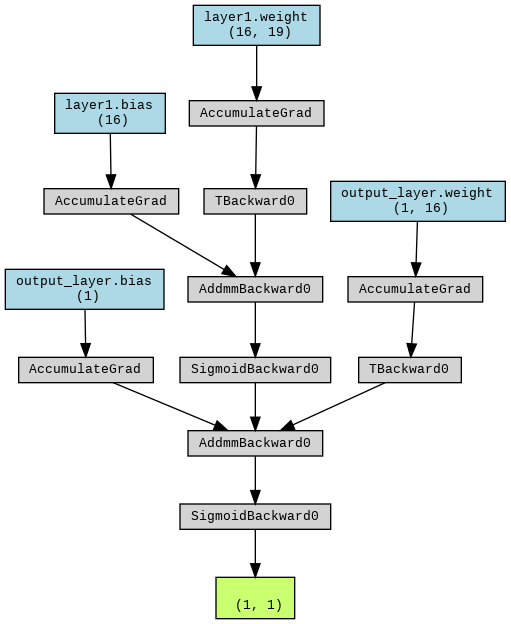

Deep NN Graph:


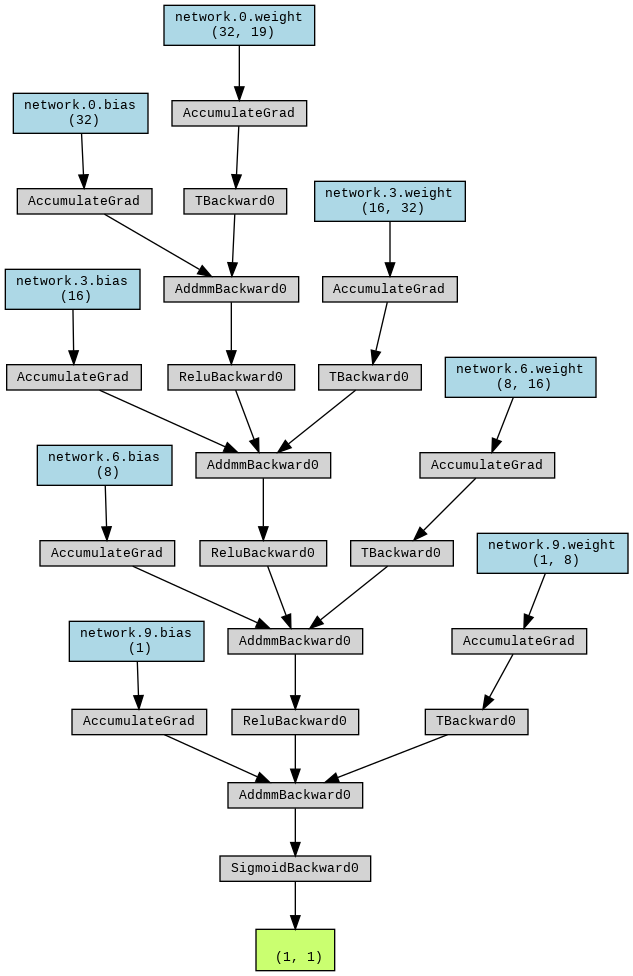

In [26]:
!pip install torchviz -q
from torchviz import make_dot

sample_input = X_tr_t[:1]
out = shallow_model(sample_input)
dot = make_dot(out, params=dict(shallow_model.named_parameters()))
dot.render("shallow_nn_graph", format="png")

out_deep = deep_model(sample_input)
dot_deep = make_dot(out_deep, params=dict(deep_model.named_parameters()))
dot_deep.render("deep_nn_graph", format="png")

from IPython.display import Image, display
print("Shallow NN Graph:")
display(Image("shallow_nn_graph.png"))
print("Deep NN Graph:")
display(Image("deep_nn_graph.png"))

## Performance Interpretation & Analysis

The Shallow Neural Network achieved a test accuracy of 80.33% with an AUC of 0.870, while the
Deep Neural Network achieved a slightly higher test accuracy of 81.97% with a stronger AUC of
0.897. The Deep NN outperformed the Shallow NN on Accuracy, Precision, F1-Score, and AUC, while
the Shallow NN achieved a higher Recall (87.88% vs 81.82%), meaning it identified a larger
proportion of actual disease cases relative to all true disease cases, at the cost of more false
positives.

Examining the training history curves, the Shallow NN showed a noticeable, persistent gap between
training and validation loss (training loss continued decreasing to roughly 0.27 while validation
loss plateaued around 0.40), indicating mild overfitting despite its simple single-hidden-layer
architecture. In contrast, the Deep NN's training and validation loss curves tracked each other
closely throughout all 100 epochs, converging together to roughly 0.40–0.41, showing that the
Dropout regularization (rate = 0.3) effectively prevented the deeper, higher-capacity architecture
from overfitting.

In terms of clinical relevance, the Shallow NN produced 4 false negatives on the test set, compared
to 6 false negatives for the Deep NN. Since missing a real disease case is more costly than a false
alarm in a medical context, this is a meaningful point in the Shallow NN's favor despite its lower
overall accuracy and AUC.

Overall, the Deep NN provided a modest improvement in most aggregate metrics (Accuracy, Precision,
F1, AUC) and generalized cleanly without overfitting, validating the use of Dropout regularization.
However, the Shallow NN's higher Recall and lower false negative count show it was actually more
conservative about missing disease cases — a meaningful tradeoff. On a dataset this small (303
samples), neither architecture dominates outright; the choice between them ultimately depends on
whether overall accuracy/AUC or minimizing missed diagnoses is prioritized.